For real-time streaming
For visualization
 For CAN data (jar vector CANoe madhla data use karaycha asel tar)
cau kannacintec (CAN library) - jar available asel tar
import can

For ECU-TEST report reading

In [1]:
import numpy as np
import pandas as pd
import sklearn
import asyncio
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import os

API for (FastAPI) and ( For API requests (external API use karaycha asel tar))

In [2]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
import requests

 For model and logging

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import logging

In [5]:
data = pd.read_csv(r"F:\Project\AI_Automative_Projects\data\used_cars.csv")
# load data 

EDA Process

In [6]:
print(data.head())

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Automatic        

In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None


In [8]:
print(data.describe())

        model_year
count  4009.000000
mean   2015.515590
std       6.104816
min    1974.000000
25%    2012.000000
50%    2017.000000
75%    2020.000000
max    2024.000000


In [18]:
print(data.isnull().sum())                                                    # 3. Missing values check kar

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [9]:
data = data.dropna()                                 # 4. Missing values handle    # OR data = data.fillna(0)

In [10]:
print(data.columns)
print(data.shape)                                         # 5. EDA - Column stats

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')
(3269, 12)


In [11]:
correlation = data.select_dtypes(include=['number']).corr()
print(correlation)                                                            # 6. Correlation matrix

            model_year
model_year         1.0


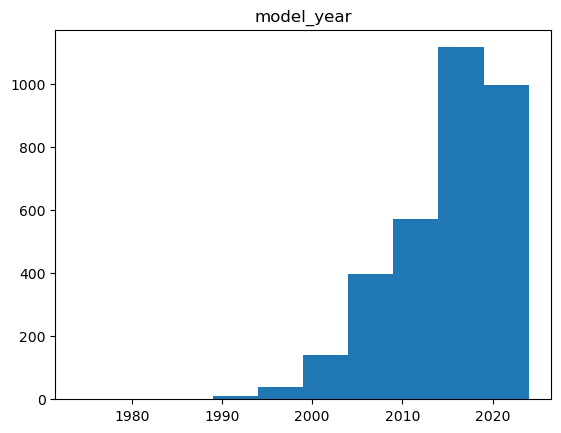

In [12]:
# 7. Visualization - Histograms
for column in data.select_dtypes(include=['number']).columns:
    plt.figure()
    plt.hist(data[column])
    plt.title(column)
    plt.savefig(f"F:/Project/AI_Automative_Projects/reports/{column}_histogram.png")

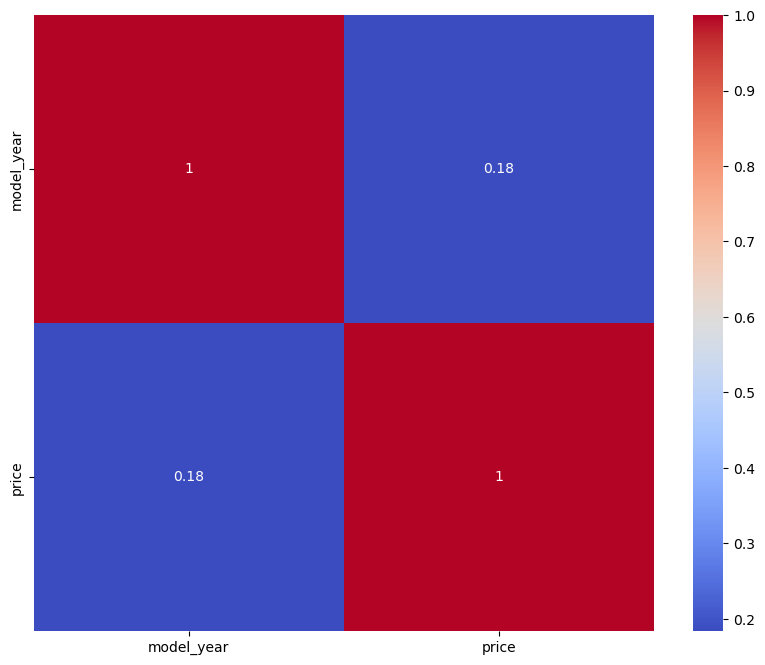

In [59]:
# 8. Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.savefig("F:/Project/AI_Automative_Projects/reports/correlation_heatmap.png")

In [13]:
# 9. Insights nikal
print("=== EDA Insights ===")
print(f"Total rows: {data.shape[0]}")
print(f"Total columns: {data.shape[1]}")
print(f"Missing values: {data.isnull().sum().sum()}")

=== EDA Insights ===
Total rows: 3269
Total columns: 12
Missing values: 0


EDA colmpleted

In [14]:
X = data.drop("price", axis=1)
y = data["price"]

In [15]:
print(X.dtypes)

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
dtype: object


text is conver into number
model training ready

In [16]:
data["price"] = data["price"].astype(str)
data["price"] = data["price"].str.replace(r"[$,]", "", regex=True)
data["price"] = data["price"].astype(float)

In [17]:
X = data.drop("price", axis=1)
y = data["price"]

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

train-test split(Regression)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)                                           # prediction
print(y_pred[:10])

[27826.05 51719.99 76889.94 40507.68 53349.38 19653.01 65331.3  60764.64
 10704.57 11291.19]


In [23]:
#Model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 17327.279877675843
MSE: 14336401588.27206
R2 Score: 0.020991066878355946


In [25]:
import pickle
os.makedirs("F:/Project/AI_Automative_Projects/model", exist_ok=True)
pickle.dump(model, open("F:/Project/AI_Automative_Projects/model/model.pkl", "wb"))

In [29]:
sample = X_test.iloc[[0]]   # double bracket important
print(model.predict(sample))

[27826.05]
